In [1]:
!pip install scikit-learn pandas matplotlib

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
assignment1 = """
Artificial intelligence is a branch of computer science.
It allows computers to perform tasks that normally require human intelligence.
Machine learning is an important part of artificial intelligence.
It helps computers learn from data and make predictions.
"""

assignment2 = """
Artificial intelligence is a field of computer science.
It enables computers to perform tasks that usually require human intelligence.
Machine learning is an important component of artificial intelligence.
It allows computers to learn from data and make predictions.
"""

assignment3 = """
The environment is very important for human life.
Trees provide oxygen and help reduce air pollution.
People should protect forests and reduce environmental pollution.
Recycling waste can help create a cleaner environment.
"""

In [4]:
print("Assignment 1:")
print(assignment1)

print("\nAssignment 2:")
print(assignment2)

print("\nAssignment 3:")
print(assignment3)

Assignment 1:

Artificial intelligence is a branch of computer science.
It allows computers to perform tasks that normally require human intelligence.
Machine learning is an important part of artificial intelligence.
It helps computers learn from data and make predictions.


Assignment 2:

Artificial intelligence is a field of computer science.
It enables computers to perform tasks that usually require human intelligence.
Machine learning is an important component of artificial intelligence.
It allows computers to learn from data and make predictions.


Assignment 3:

The environment is very important for human life.
Trees provide oxygen and help reduce air pollution.
People should protect forests and reduce environmental pollution.
Recycling waste can help create a cleaner environment.



In [5]:
def preprocess_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [6]:
clean_assignment1 = preprocess_text(assignment1)

clean_assignment2 = preprocess_text(assignment2)

clean_assignment3 = preprocess_text(assignment3)

print("Assignment 1:")
print(clean_assignment1)

print("\nAssignment 2:")
print(clean_assignment2)

print("\nAssignment 3:")
print(clean_assignment3)

Assignment 1:
artificial intelligence is a branch of computer science it allows computers to perform tasks that normally require human intelligence machine learning is an important part of artificial intelligence it helps computers learn from data and make predictions

Assignment 2:
artificial intelligence is a field of computer science it enables computers to perform tasks that usually require human intelligence machine learning is an important component of artificial intelligence it allows computers to learn from data and make predictions

Assignment 3:
the environment is very important for human life trees provide oxygen and help reduce air pollution people should protect forests and reduce environmental pollution recycling waste can help create a cleaner environment


In [7]:
assignments = [
    clean_assignment1,
    clean_assignment2,
    clean_assignment3
]

print("Total Assignments:", len(assignments))

Total Assignments: 3


In [8]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(assignments)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (3, 55)


In [9]:
feature_names = vectorizer.get_feature_names_out()

print("Vocabulary:")
print(feature_names)

Vocabulary:
['air' 'allows' 'an' 'and' 'artificial' 'branch' 'can' 'cleaner'
 'component' 'computer' 'computers' 'create' 'data' 'enables'
 'environment' 'environmental' 'field' 'for' 'forests' 'from' 'help'
 'helps' 'human' 'important' 'intelligence' 'is' 'it' 'learn' 'learning'
 'life' 'machine' 'make' 'normally' 'of' 'oxygen' 'part' 'people'
 'perform' 'pollution' 'predictions' 'protect' 'provide' 'recycling'
 'reduce' 'require' 'science' 'should' 'tasks' 'that' 'the' 'to' 'trees'
 'usually' 'very' 'waste']


In [10]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity Matrix:")
print(similarity_matrix)

Similarity Matrix:
[[1.         0.8620819  0.06313554]
 [0.8620819  1.         0.06139392]
 [0.06313554 0.06139392 1.        ]]


In [11]:
similarity_percentage = similarity_matrix * 100

print("Similarity Percentage:")
print(similarity_percentage)

Similarity Percentage:
[[100.          86.20818955   6.31355371]
 [ 86.20818955 100.           6.13939242]
 [  6.31355371   6.13939242 100.        ]]


In [12]:
results = pd.DataFrame(
    similarity_percentage,
    columns=[
        "Assignment 1",
        "Assignment 2",
        "Assignment 3"
    ],
    index=[
        "Assignment 1",
        "Assignment 2",
        "Assignment 3"
    ]
)

print(results.round(2))

              Assignment 1  Assignment 2  Assignment 3
Assignment 1        100.00         86.21          6.31
Assignment 2         86.21        100.00          6.14
Assignment 3          6.31          6.14        100.00


In [13]:
similarity = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:2]
)[0][0]

print(
    "Assignment 1 vs Assignment 2:",
    round(similarity * 100, 2),
    "%"
)

Assignment 1 vs Assignment 2: 86.21 %


In [14]:
def check_plagiarism(similarity_score, threshold=70):
    
    similarity_percentage = similarity_score * 100
    
    if similarity_percentage >= threshold:
        return "High Similarity / Possible Plagiarism"
    
    elif similarity_percentage >= 40:
        return "Moderate Similarity"
    
    else:
        return "Low Similarity / Likely Original"

In [15]:
result = check_plagiarism(similarity)

print("Similarity:", round(similarity * 100, 2), "%")

print("Result:", result)

Similarity: 86.21 %
Result: High Similarity / Possible Plagiarism


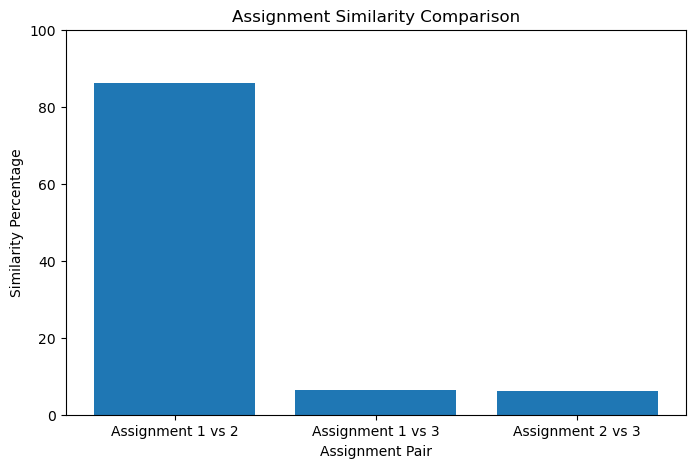

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Assignment 1 vs 2", "Assignment 1 vs 3", "Assignment 2 vs 3"],
    [
        similarity_matrix[0][1] * 100,
        similarity_matrix[0][2] * 100,
        similarity_matrix[1][2] * 100
    ]
)

plt.title("Assignment Similarity Comparison")

plt.xlabel("Assignment Pair")

plt.ylabel("Similarity Percentage")

plt.ylim(0, 100)

plt.show()

In [18]:
text1 = input("Enter Assignment 1: ")

text2 = input("Enter Assignment 2: ")

Enter Assignment 1:  Artificial intelligence is a branch of computer science. Machine learning allows computers to learn from data and make predictions.
Enter Assignment 2:  Trees are important for the environment. They provide oxygen, reduce pollution, and protect wildlife.


In [ ]:
text1 = preprocess_text(text1)

text2 = preprocess_text(text2)

print("\nCleaned Assignment 1:")
print(text1)

print("\nCleaned Assignment 2:")
print(text2)

In [ ]:
user_assignments = [
    text1,
    text2
]

user_vectorizer = TfidfVectorizer()

user_tfidf = user_vectorizer.fit_transform(
    user_assignments
)

user_similarity = cosine_similarity(
    user_tfidf[0:1],
    user_tfidf[1:2]
)[0][0]

print(
    "\nSimilarity Percentage:",
    round(user_similarity * 100, 2),
    "%"
)

In [ ]:
final_result = check_plagiarism(
    user_similarity
)

print("\nFinal Result:")
print(final_result)